In [1]:
# BDPA project

In [2]:
# Creating a spark session
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import sys
from pyspark.sql import SparkSession

spark = SparkSession.builder \
 .master("local") \
 .appName("BDPA_project") \
 .getOrCreate()

PATH_TO_DATA = "data/final_dataset.csv"

In [3]:
# reading data
df = spark.read.csv(PATH_TO_DATA, header=True, inferSchema=True)
#df.show(vertical=True)
#df.count()

In [4]:
# Converting spark data to a pandas dataframe
import pandas as pd
dff = df.toPandas()
dff

,iso3,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,gdp_per_capita_2022,gdp_2022,urban_population_2022,population_density_2022,pollution_mortality_2019
0,CIV,Côte d'Ivoire,Grand Lahou,54,Moderate,1,Good,25,Good,0,Good,54,Moderate,2333.371283,7.092282e+10,52.849255,95.581767,186.5
1,CIV,Côte d'Ivoire,Abidjan,105,Unhealthy for Sensitive Groups,4,Good,15,Good,4,Good,105,Unhealthy for Sensitive Groups,2333.371283,7.092282e+10,52.849255,95.581767,186.5
2,CIV,Côte d'Ivoire,Issia,84,Moderate,2,Good,10,Good,1,Good,84,Moderate,2333.371283,7.092282e+10,52.849255,95.581767,186.5
3,CIV,Côte d'Ivoire,Gagnoa,39,Good,1,Good,18,Good,0,Good,39,Good,2333.371283,7.092282e+10,52.849255,95.581767,186.5
4,CIV,Côte d'Ivoire,Alepe,41,Good,1,Good,23,Good,0,Good,41,Good,2333.371283,7.092282e+10,52.849255,95.581767,186.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23458,NLD,Netherlands,Oud Beijerland,34,Good,0,Good,34,Good,2,Good,31,Good,59123.318556,1.046541e+12,94.985618,525.719691,13.1
23459,NLD,Netherlands,Kesteren,37,Good,1,Good,31,Good,3,Good,37,Good,59123.318556,1.046541e+12,94.985618,525.719691,13.1
23460,NLD,Netherlands,Meerssen,55,Moderate,1,Good,39,Good,1,Good,55,Moderate,59123.318556,1.046541e+12,94.985618,525.719691,13.1
23461,NLD,Netherlands,Duiven,30,Good,1,Good,30,Good,2,Good,21,Good,59123.318556,1.046541e+12,94.985618,525.719691,13.1


In [5]:
# Setting up matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-white')
params = {'legend.fontsize': 'large',
    'figure.figsize': (15, 9),
    'axes.labelsize': 'x-large',
    'axes.titlesize':'x-large',
    'xtick.labelsize':'large',
    'ytick.labelsize':'large'}

# Replacing possible missing values with NaNs
dff['AQI value'] = pd.to_numeric(dff['AQI Value'],errors='coerce')
dff['urban_population_2022'] = pd.to_numeric(dff['urban_population_2022'],errors='coerce')
dff['gdp_per_capita_2022'] = pd.to_numeric(dff['gdp_per_capita_2022'],errors='coerce')
dff['gdp_2022'] = pd.to_numeric(dff['gdp_2022'],errors='coerce')
dff['population_density_2022'] = pd.to_numeric(dff['population_density_2022'],errors='coerce')
dff['pollution_mortality_2019'] = pd.to_numeric(dff['pollution_mortality_2019'],errors='coerce')

<Axes: xlabel='AQI Value', ylabel='urban_population_2022'>

-0.4491621406823735

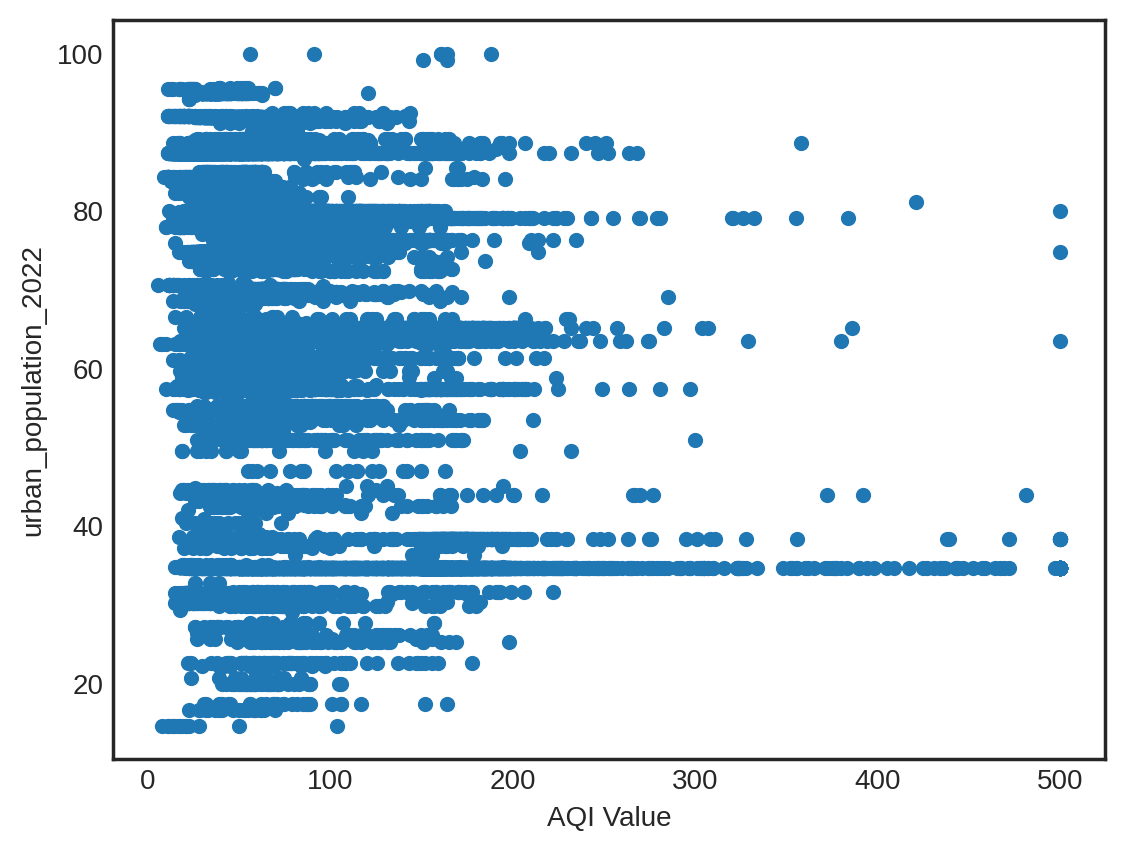

In [6]:
# 1.1 How does AQI relate to urbanization

dff.plot(kind='scatter',x='AQI Value',y='urban_population_2022')
dff["AQI Value"].corr(dff["urban_population_2022"], method="pearson")
# Pearson correlation = -0.45 -> moderate negative correlation -> when AQI value rises, urbanization goes down

<Axes: xlabel='AQI Value', ylabel='gdp_per_capita_2022'>

-0.28413381392770354

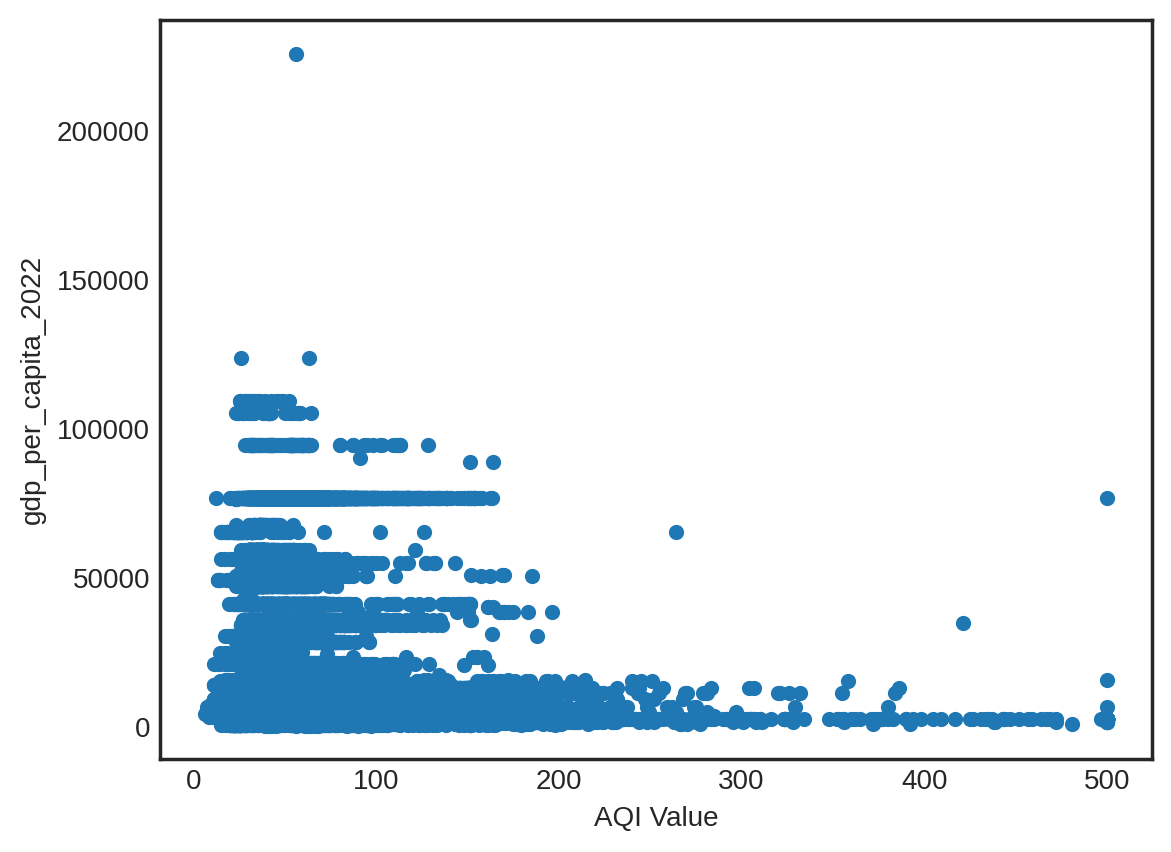

In [7]:
# 1.2 How does AQI relate to GDP per capita

dff.plot(kind='scatter',x='AQI Value',y='gdp_per_capita_2022')
dff["AQI Value"].corr(dff["gdp_per_capita_2022"], method="pearson")
# Pearson correlation = -0.28 -> weak negative correlation -> when AQI value rises, GDP per capita goes down

<Axes: xlabel='AQI Value', ylabel='gdp_2022'>

0.0034596602123386513

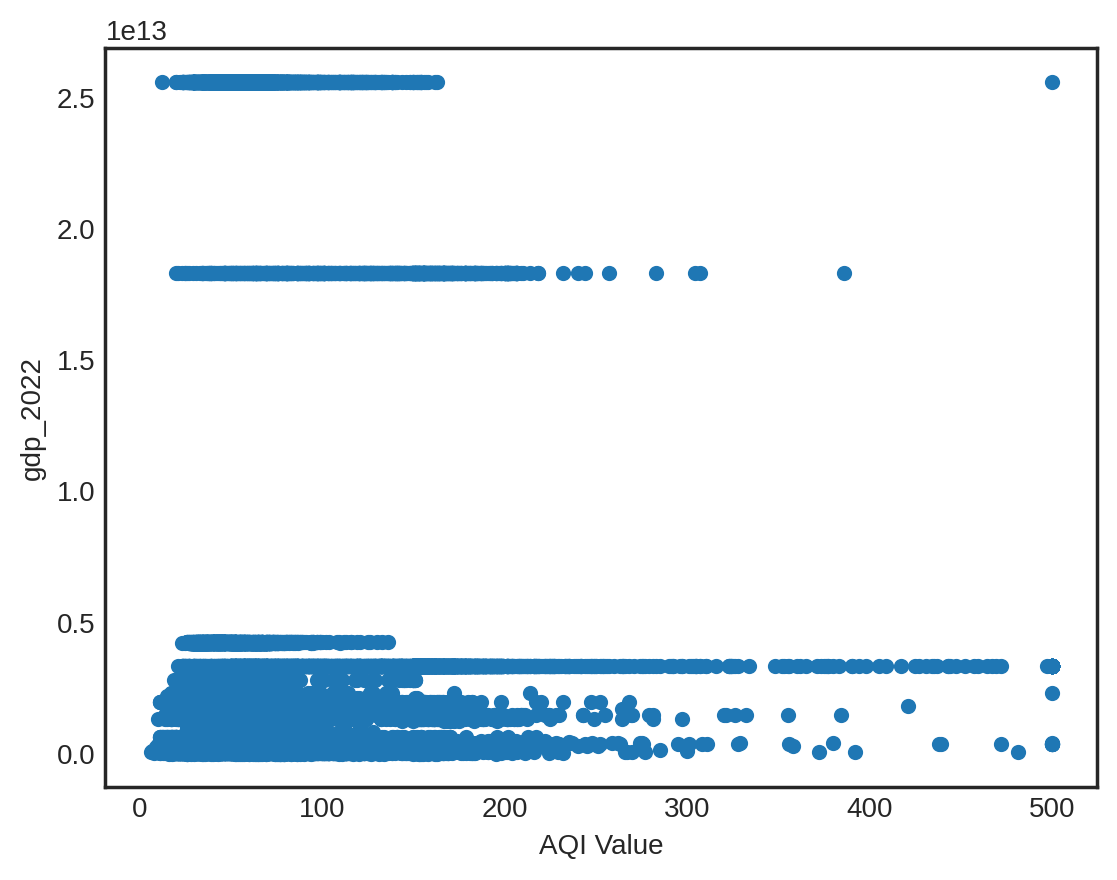

In [8]:
# 1.3 How does AQI relate to GDP

dff.plot(kind='scatter',x='AQI Value',y='gdp_2022')
dff["AQI Value"].corr(dff["gdp_2022"], method="pearson")
# Pearson correlation = 0.00 -> no correlation -> no noticeable link between AQI and GDP

<Axes: xlabel='AQI Value', ylabel='population_density_2022'>

0.2894240149822199

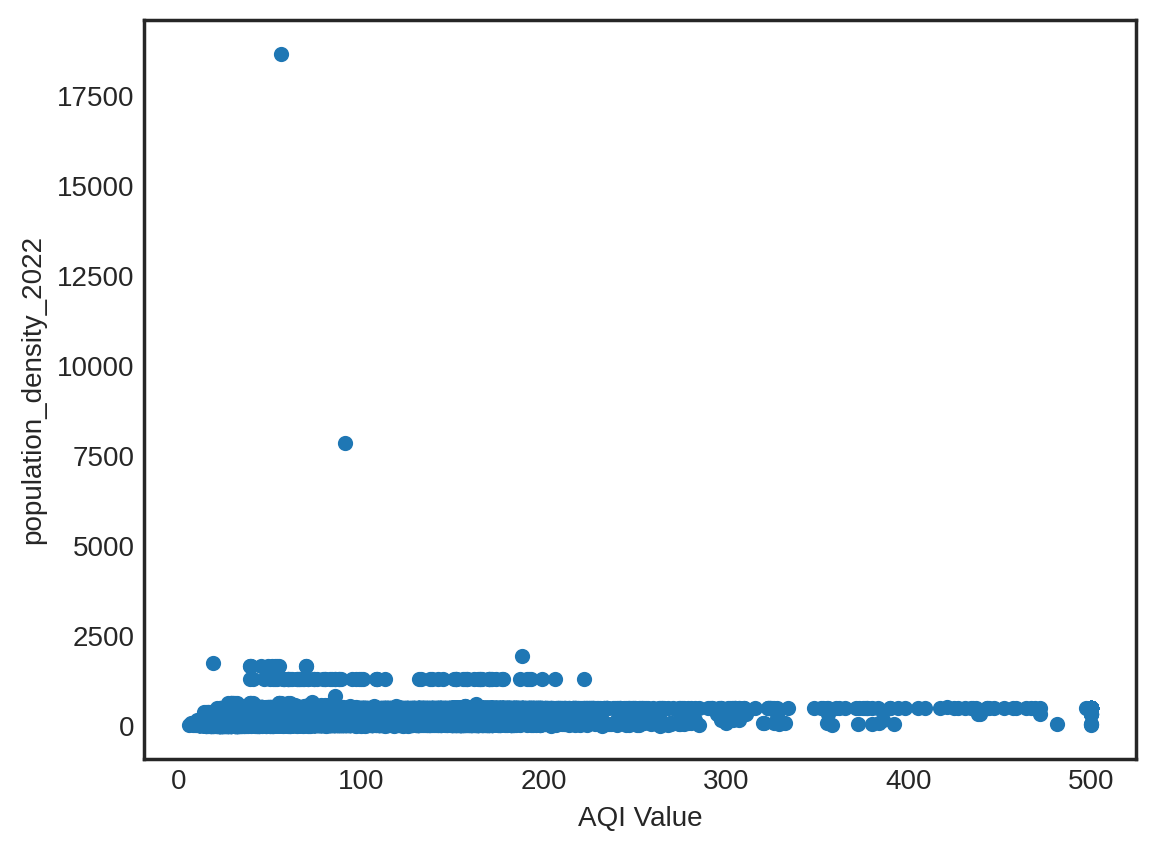

In [9]:
# 1.4 How does AQI relate to population density

dff.plot(kind='scatter',x='AQI Value',y='population_density_2022')
dff["AQI Value"].corr(dff["population_density_2022"], method="pearson")
# Pearson correlation = 0.29 -> weak correlation -> when AQI value rises, population density rises

<Axes: xlabel='AQI Value', ylabel='pollution_mortality_2019'>

0.412456932923094

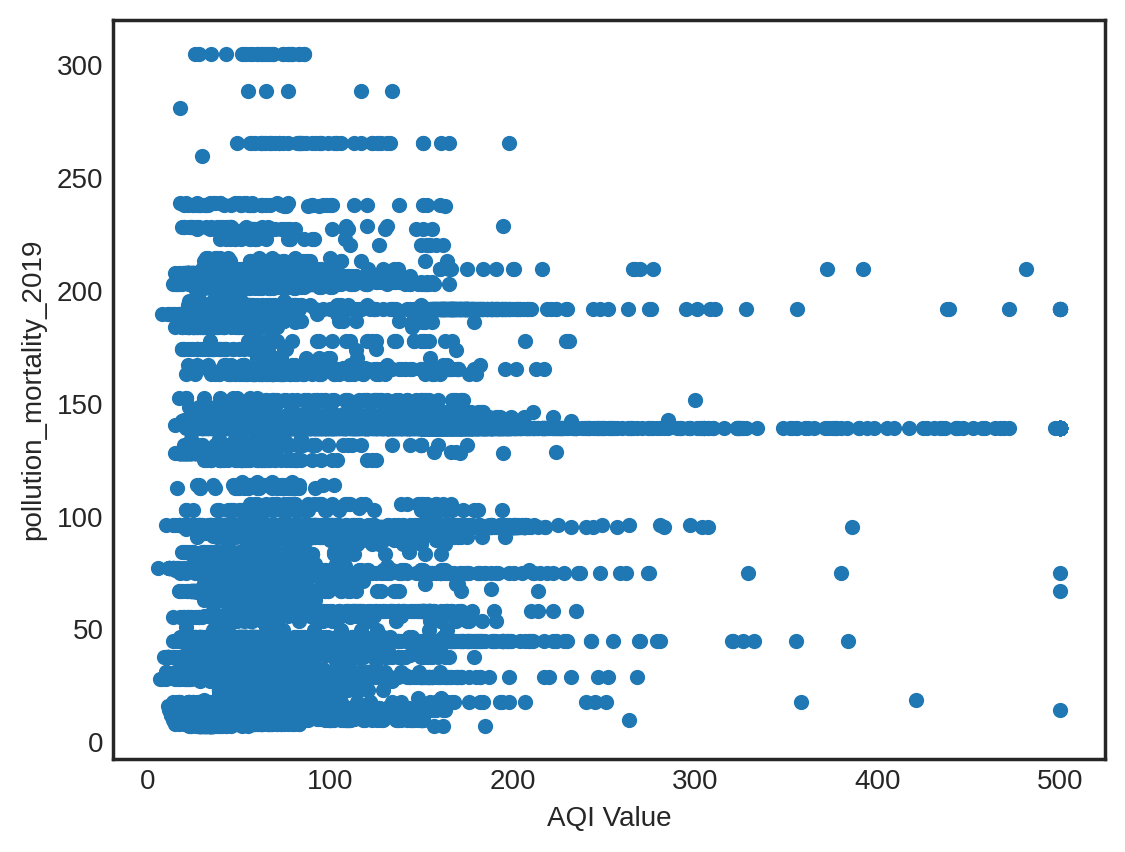

In [10]:
# 1.5 How does AQI relate to pollution mortality

dff.plot(kind='scatter',x='AQI Value',y='pollution_mortality_2019')
dff["AQI Value"].corr(dff["pollution_mortality_2019"], method="pearson")
# Pearson correlation = 0.41 -> moderate correlation -> when AQI value rises, pollution mortality rises

In [11]:
# 2. How do pollution types (CO, Ozone, NO2, PM2.5) correlate with how developed the country is (GDP per capita)?

# Calculating correlation for each pollutant
corrs = dff[["gdp_per_capita_2022", "CO AQI Value", "Ozone AQI Value", "NO2 AQI Value", "PM2.5 AQI Value"]].corr(method="pearson")
print(corrs["gdp_per_capita_2022"])
# CO -0.09 very weak negative correlation
# Ozone -0.11 very weak negative correlation
# NO2 0.30 weak positive correlation
# PM2.5 -0-29 weak negative correlation

gdp_per_capita_2022    1.000000
CO AQI Value          -0.093847
Ozone AQI Value       -0.105010
NO2 AQI Value          0.295404
PM2.5 AQI Value       -0.289665
Name: gdp_per_capita_2022, dtype: float64


Text(0.5, 0, 'GDP per capita')

Text(0, 0.5, 'CO AQI Value')

Text(0.5, 1.0, 'CO AQI Value vs GDP per capita')

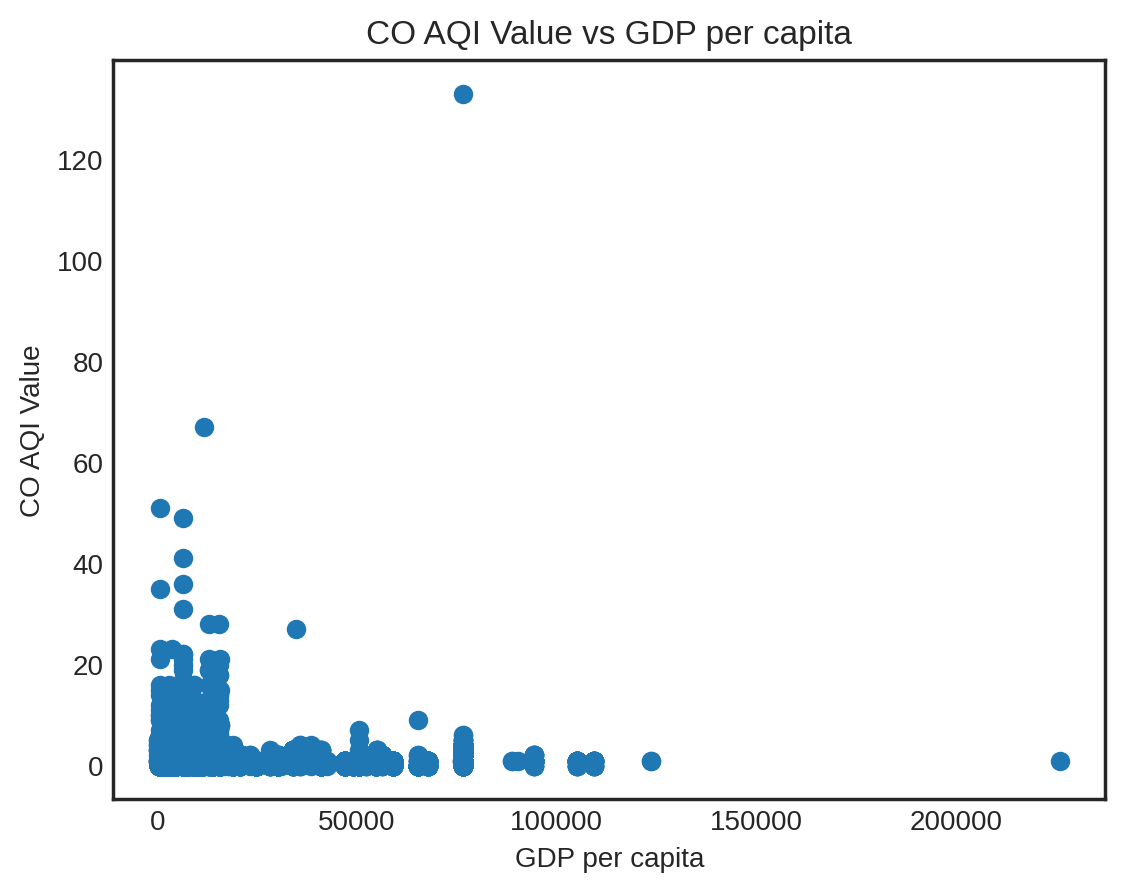

Text(0.5, 0, 'GDP per capita')

Text(0, 0.5, 'Ozone AQI Value')

Text(0.5, 1.0, 'Ozone AQI Value vs GDP per capita')

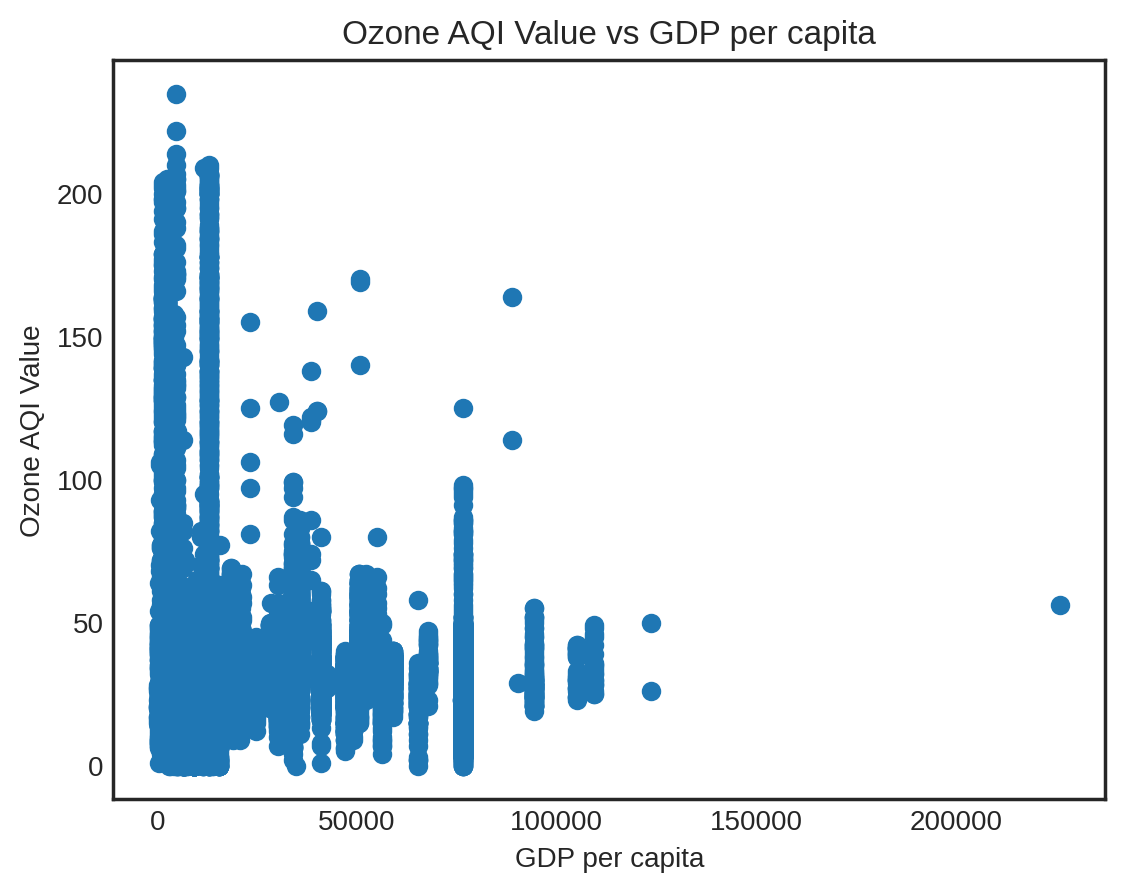

Text(0.5, 0, 'GDP per capita')

Text(0, 0.5, 'NO2 AQI Value')

Text(0.5, 1.0, 'NO2 AQI Value vs GDP per capita')

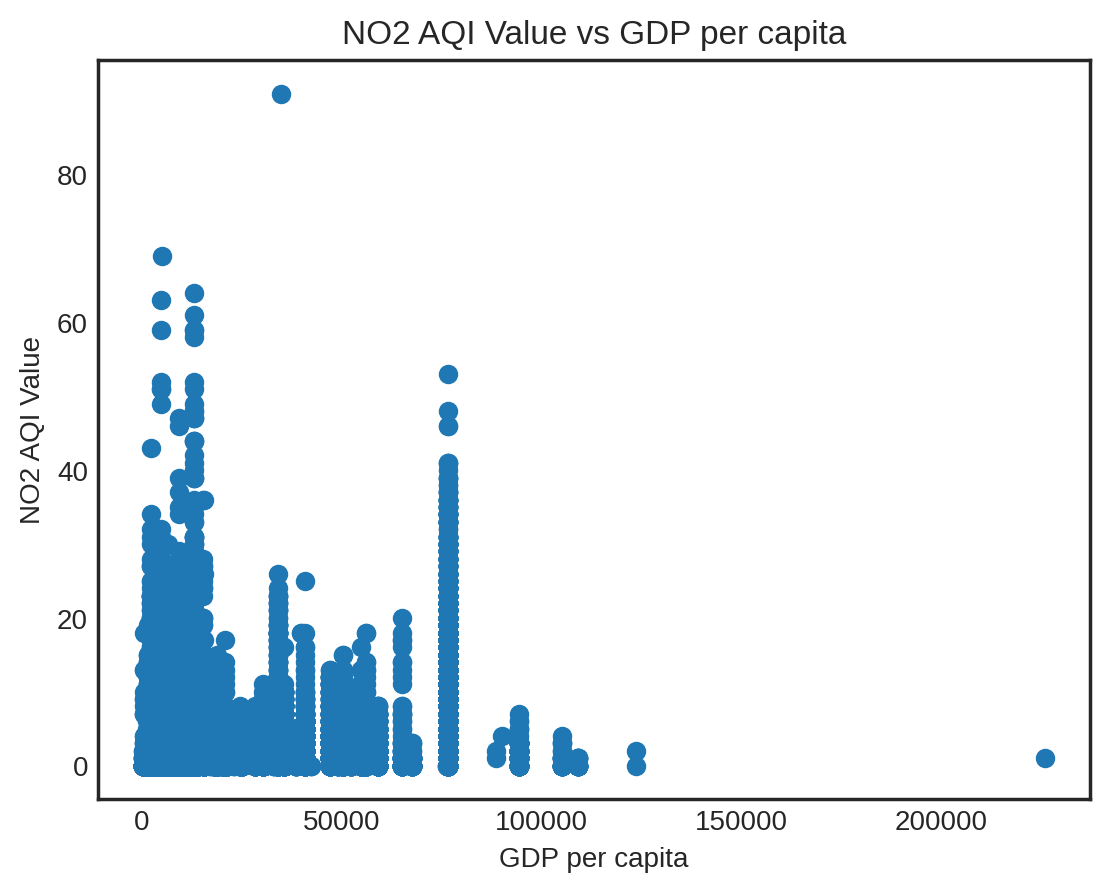

Text(0.5, 0, 'GDP per capita')

Text(0, 0.5, 'PM2.5 AQI Value')

Text(0.5, 1.0, 'PM2.5 AQI Value vs GDP per capita')

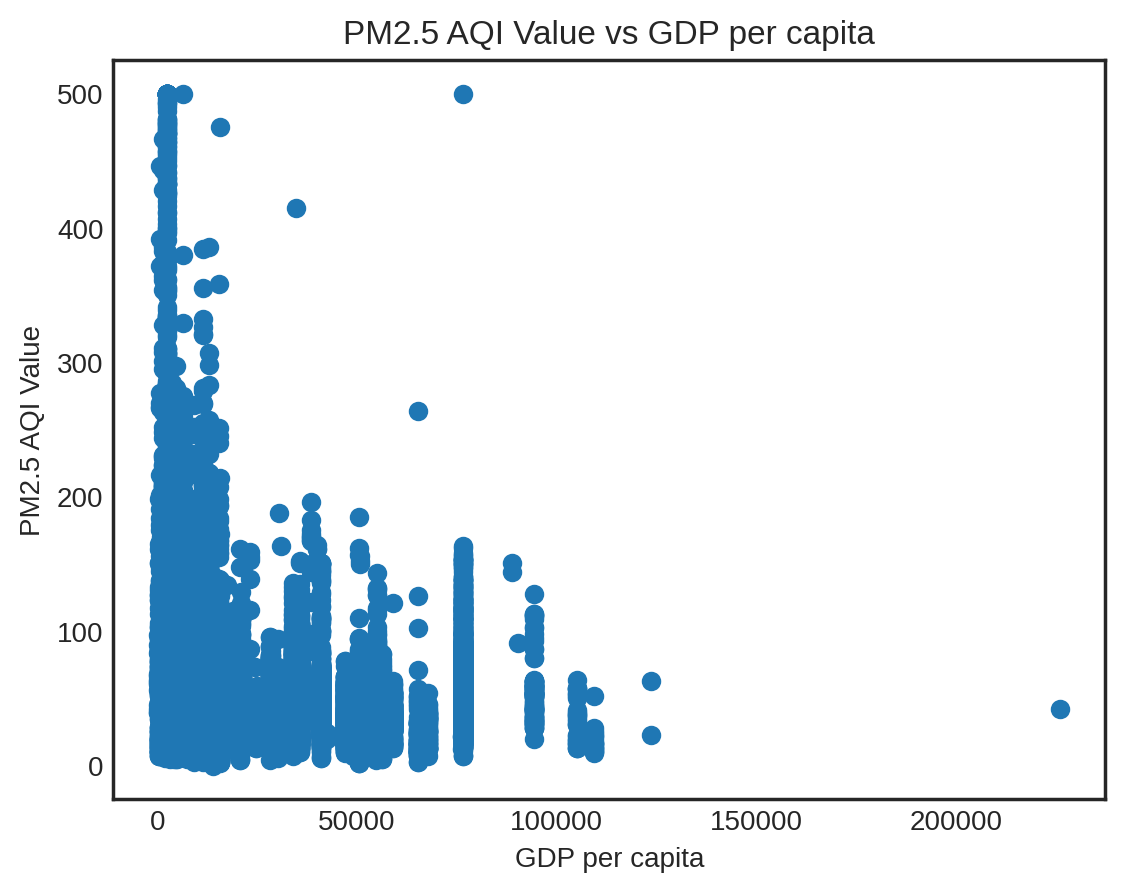

In [12]:
# Visualizing
for col in ["CO AQI Value", "Ozone AQI Value", "NO2 AQI Value", "PM2.5 AQI Value"]:
    plt.scatter(dff["gdp_per_capita_2022"], dff[col])
    plt.xlabel("GDP per capita")
    plt.ylabel(col)
    plt.title(f"{col} vs GDP per capita")
    plt.show()